In [208]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [209]:
digits = load_digits()

X = digits.data
y = digits.target

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (1797, 64)
Shape of y: (1797,)


In [210]:
print(f"Number of classes: {len(set(y))}")

print(f"classes: {digits.target_names}")

Number of classes: 10
classes: [0 1 2 3 4 5 6 7 8 9]


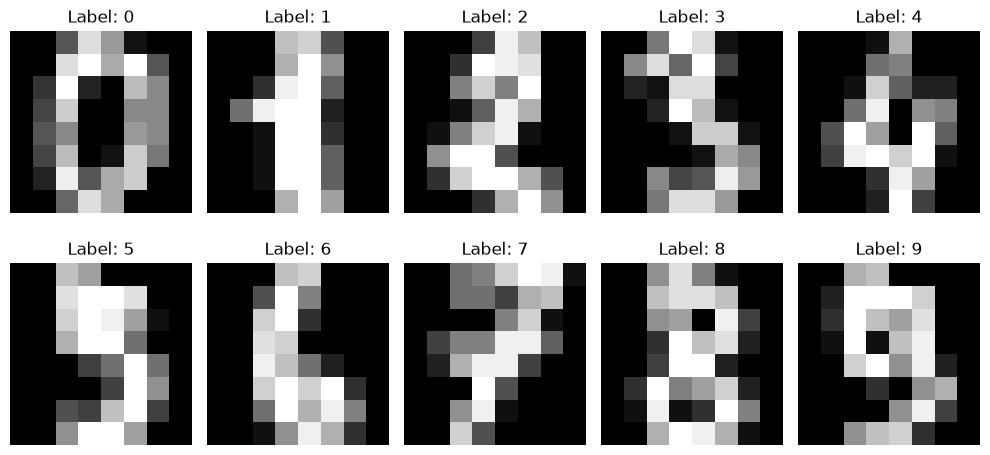

In [211]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.ravel()):
    ax.imshow(
        digits.images[i],
        cmap="gray"
    )

    ax.set_title(
        f"Label: {digits.target[i]}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [212]:
print(digits.images[0])

[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]


In [213]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,stratify=y)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [214]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)


print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: torch.Size([1437, 64])
y_train shape: torch.Size([1437])


In [215]:
class LinearSVM(nn.Module):
    def __init__(self, inout_dim, num_classes):
        super(LinearSVM, self).__init__()
        self.linear = nn.Linear(inout_dim, num_classes)

    def forward(self, x):

        return self.linear(x)

In [216]:
model = LinearSVM(inout_dim=X_train.shape[1], num_classes=len(set(y)))

In [217]:
sample = X_train[0].unsqueeze(0)

scores = model(sample)

print("Scores shape:", scores.shape)
print(scores)

Scores shape: torch.Size([1, 10])
tensor([[-0.0338, -1.2085, -1.5289,  0.3552,  0.1103,  0.2939, -0.5023, -0.1944,
          0.5185,  0.5243]], grad_fn=<AddmmBackward0>)


In [218]:
def multiclass_hinge_loss(scores, labels, delta=1.0):
    """
    Computes the multiclass hinge loss.

    Args:
        scores (torch.Tensor): The predicted scores for each class.
        labels (torch.Tensor): The true labels.
        delta (float): The margin parameter.

    Returns:
        torch.Tensor: The computed hinge loss.
    """
    # Get the correct class scores
    correct_class_scores = scores[range(scores.shape[0]), labels].unsqueeze(1)

    # Compute the margins
    margins = torch.clamp(scores - correct_class_scores + delta, min=0)

    # Zero out the correct class margins
    margins[range(scores.shape[0]), labels] = 0

    # Compute the loss
    loss = torch.mean(torch.sum(margins, dim=1))

    return loss

In [219]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)


In [220]:
epochs = 1000

loss_history = []

for epoch in range(epochs):

    scores = model(X_train)

    loss = multiclass_hinge_loss(scores, y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    loss_history.append(loss.item())

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [100/1000], Loss: 0.4011
Epoch [200/1000], Loss: 0.2598
Epoch [300/1000], Loss: 0.2037
Epoch [400/1000], Loss: 0.1715
Epoch [500/1000], Loss: 0.1508
Epoch [600/1000], Loss: 0.1356
Epoch [700/1000], Loss: 0.1241
Epoch [800/1000], Loss: 0.1148
Epoch [900/1000], Loss: 0.1070
Epoch [1000/1000], Loss: 0.1003


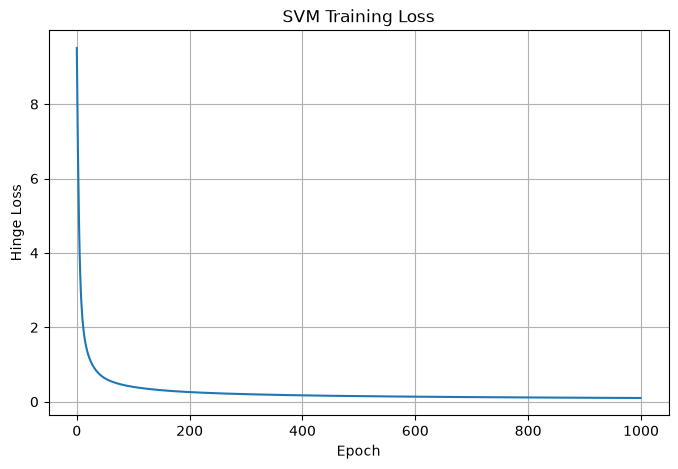

In [221]:
plt.figure(figsize=(8, 5))

plt.plot(
    loss_history
)

plt.xlabel("Epoch")
plt.ylabel("Hinge Loss")
plt.title("SVM Training Loss")

plt.grid()

plt.show()

In [222]:
with torch.no_grad():

    test_scores = model(X_test)

    y_pred = torch.argmax(test_scores,dim=1)

In [223]:
print("Predicted:")
print(y_pred[:20])

print("\nActual:")
print(y_test[:20])

Predicted:
tensor([5, 2, 8, 6, 7, 2, 6, 2, 6, 5, 0, 5, 9, 3, 4, 4, 2, 4, 7, 9])

Actual:
tensor([5, 2, 8, 1, 7, 2, 6, 2, 6, 5, 0, 5, 9, 3, 4, 4, 2, 4, 9, 9])


In [224]:
accuracy = (y_pred == y_test).float().mean()

print(f"Accuracy: {accuracy.item():.4f}")

Accuracy: 0.9528


In [225]:
cm = confusion_matrix(y_test.numpy(),y_pred.numpy())

print(cm)

[[36  0  0  0  0  0  0  0  0  0]
 [ 0 30  0  1  0  1  1  0  1  2]
 [ 0  0 35  0  0  0  0  0  0  0]
 [ 0  0  0 36  0  1  0  0  0  0]
 [ 0  0  0  0 36  0  0  0  0  0]
 [ 0  0  0  0  0 36  0  0  0  1]
 [ 0  1  0  0  0  0 34  0  1  0]
 [ 0  0  0  0  0  0  0 36  0  0]
 [ 0  2  1  0  0  0  0  2 30  0]
 [ 0  0  0  0  0  0  0  1  1 34]]


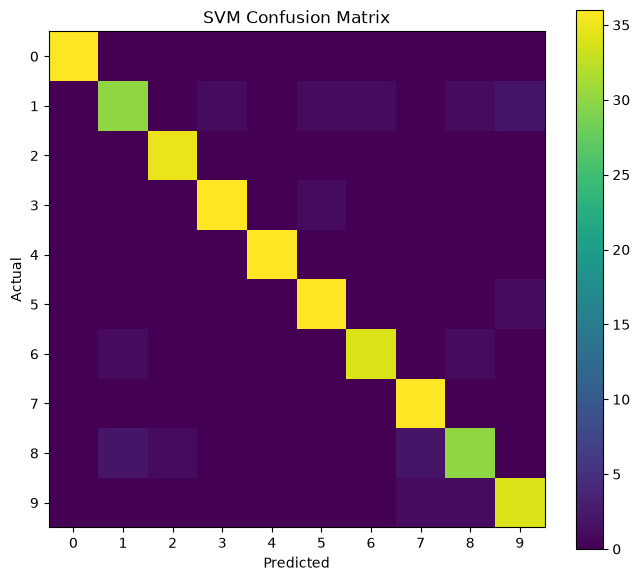

In [226]:
plt.figure(figsize=(8, 7))

plt.imshow(cm)

plt.title("SVM Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    range(10),
    range(10)
)

plt.yticks(
    range(10),
    range(10)
)

plt.colorbar()

plt.show()

In [227]:
print(classification_report( y_test.numpy(), y_pred.numpy()))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.91      0.83      0.87        36
           2       0.97      1.00      0.99        35
           3       0.97      0.97      0.97        37
           4       1.00      1.00      1.00        36
           5       0.95      0.97      0.96        37
           6       0.97      0.94      0.96        36
           7       0.92      1.00      0.96        36
           8       0.91      0.86      0.88        35
           9       0.92      0.94      0.93        36

    accuracy                           0.95       360
   macro avg       0.95      0.95      0.95       360
weighted avg       0.95      0.95      0.95       360



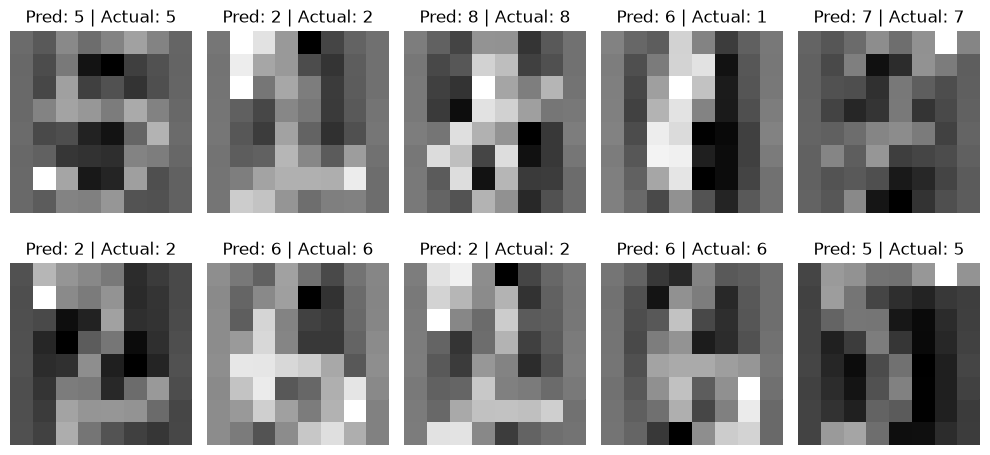

In [228]:
fig, axes = plt.subplots(
    2,
    5,
    figsize=(10, 5)
)

for i, ax in enumerate(
    axes.ravel()
):

    ax.imshow(
        X_test[i].reshape(8, 8),
        cmap="gray"
    )

    ax.set_title(
        f"Pred: {y_pred[i].item()} | "
        f"Actual: {y_test[i].item()}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [229]:
wrong_indices = torch.where(y_pred != y_test)[0]

print("Incorrect predictions:",len(wrong_indices))

Incorrect predictions: 17


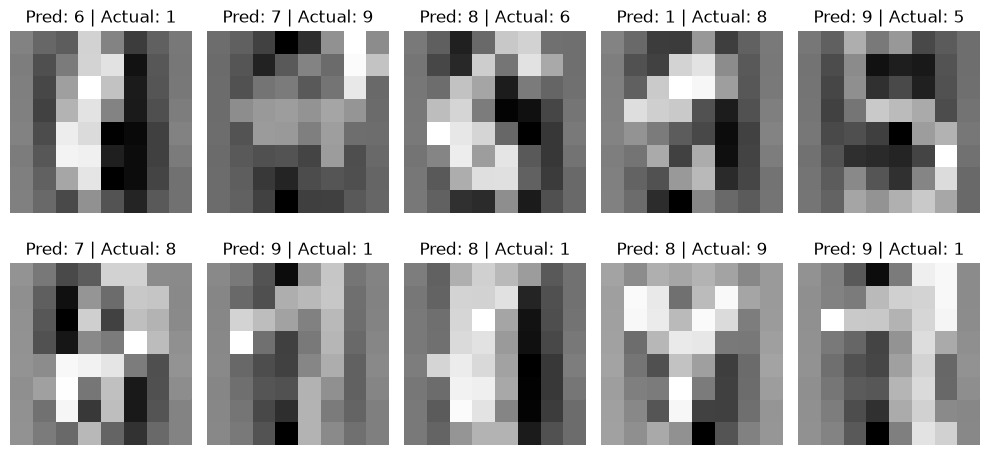

In [230]:
num_images = min(
    10,
    len(wrong_indices)
)

fig, axes = plt.subplots(
    2,
    5,
    figsize=(10, 5)
)

for i in range(num_images):

    index = wrong_indices[i]

    axes.ravel()[i].imshow(
        X_test[index].reshape(8, 8),
        cmap="gray"
    )

    axes.ravel()[i].set_title(
        f"Pred: {y_pred[index].item()} | "
        f"Actual: {y_test[index].item()}"
    )

    axes.ravel()[i].axis("off")

for i in range(num_images, 10):
    axes.ravel()[i].axis("off")

plt.tight_layout()
plt.show()

In [231]:
learning_rates = [0.001, 0.005, 0.01, 0.05, 0.1]

results = []

for lr in learning_rates:

    model_temp = LinearSVM(inout_dim=X_train.shape[1], num_classes=len(set(y)))

    optimizer_temp = torch.optim.SGD(model_temp.parameters(), lr=lr)

    for epoch in range(100):

        scores = model_temp(X_train)

        loss = multiclass_hinge_loss(scores, y_train)

        optimizer_temp.zero_grad()

        loss.backward()

        optimizer_temp.step()

    with torch.no_grad():
        
        predictions = torch.argmax(model_temp(X_test), dim=1)

        accuracy = (predictions == y_test).float().mean().item() 

    results.append((lr, accuracy))

    print(f"Learning Rate: {lr}, Accuracy: {accuracy:.4f}")


Learning Rate: 0.001, Accuracy: 0.6889
Learning Rate: 0.005, Accuracy: 0.8889
Learning Rate: 0.01, Accuracy: 0.9444
Learning Rate: 0.05, Accuracy: 0.9444
Learning Rate: 0.1, Accuracy: 0.9472


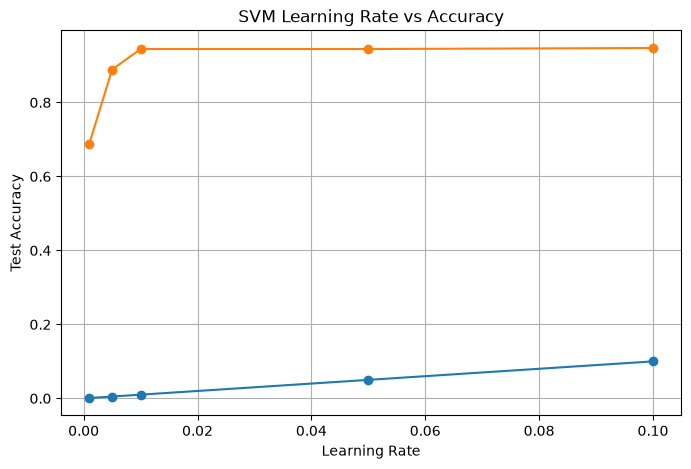

In [232]:
plt.figure(figsize=(8, 5))

plt.plot(
    learning_rates,
    results,
    marker="o"
)

plt.xlabel("Learning Rate")
plt.ylabel("Test Accuracy")

plt.title(
    "SVM Learning Rate vs Accuracy"
)

plt.grid()

plt.show()